# 🎓 Modelo Predictivo de Trayectorias Académicas
## Versión 3 — Predictor Determinista Completo

**Institución:** Universidad del Norte  
**Dataset:** 106,476 registros · 11,929 estudiantes · 20+ programas  
**Metodología:** Autómata Finito + Predicción Determinista por Transición  

---

### ¿Qué hace este notebook?

Este notebook construye y evalúa un modelo que predice el **estado académico siguiente** de cada estudiante, periodo a periodo, usando las reglas del autómata finito de trayectorias.

| Fase | Descripción |
|------|-------------|
| **0** | Instalación y configuración |
| **1** | Carga de datos |
| **2** | Extracción correcta del estado siguiente |
| **3** | Predictor determinista v3 |
| **4** | Evaluación completa con todas las clases |
| **5** | Visualizaciones (8 figuras) |
| **6** | Exportar resultados |

### ¿Por qué versión 3?

- **v1 (XGBoost):** usaba PPP y PPA → no distinguía entre Grado, PFU y Continuo regular. Accuracy ~83%
- **v2 (Determinista):** corregía v1 pero usaba `shift()` para obtener el estado siguiente → omitía Grado (9,994 casos), Reingreso (1,447), Final (2,160), Transferencia (544) y Reinicio (128)
- **v3 (esta versión):** extrae el estado siguiente desde **toda la secuencia de reglas del autómata**, no solo las filas `ACADEMIC_TRANSITION`. Accuracy: **~99%** con todas las clases correctamente representadas


## Fase 0 — Instalación de dependencias

Ejecuta esta celda una sola vez para instalar los paquetes necesarios.

In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Instala dependencias (descomenta si es necesario)
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import json
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✓ Librerías cargadas correctamente")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")


✓ Librerías cargadas correctamente
  pandas  2.3.3
  numpy   2.2.5


## Fase 1 — Configuración de rutas y carga de datos

Ajusta las rutas `FILE_MAIN` y `FILE_GRAD` según tu entorno.

| Entorno | Ejemplo de ruta |
|---------|----------------|
| **Mismo directorio** | `'12_only_undergraduate_with_automaton.xlsx'` |
| **Subcarpeta /datos** | `'../datos/12_only_undergraduate_with_automaton.xlsx'` |
| **Google Colab** | `'/content/12_only_undergraduate_with_automaton.xlsx'` |


In [2]:
# ══════════════════════════════════════════════════════════
# AJUSTA AQUÍ LAS RUTAS DE TUS ARCHIVOS
# ══════════════════════════════════════════════════════════
FILE_MAIN  = 'uploads/12_only_undergraduate_with_automaton.xlsx'
FILE_GRAD  = 'uploads/07_undergraduate_pathway with degree automaton.xlsx'
OUTPUT_DIR = './outputs_v3'
# ══════════════════════════════════════════════════════════

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verificar que los archivos existen
for f in [FILE_MAIN, FILE_GRAD]:
    status = "✓ Encontrado" if os.path.exists(f) else "✗ NO encontrado — ajusta la ruta"
    print(f"  {status}: {f}")


  ✓ Encontrado: uploads/12_only_undergraduate_with_automaton.xlsx
  ✓ Encontrado: uploads/07_undergraduate_pathway with degree automaton.xlsx


In [3]:
# Carga de los dos datasets
print("Cargando datos (puede tardar 30-60 segundos)...")

df_main = pd.read_excel(FILE_MAIN, engine='openpyxl')
df_grad = pd.read_excel(FILE_GRAD, engine='openpyxl')

# Columnas en común entre ambos archivos
common_cols = [c for c in df_main.columns if c in df_grad.columns]

# Combinar en un único DataFrame
all_df = pd.concat([df_main, df_grad[common_cols]], ignore_index=True)
all_df = all_df.sort_values(['ID', 'ORDEN_AUTOMATA']).reset_index(drop=True)

print(f"\n✓ Dataset principal : {df_main.shape[0]:,} filas × {df_main.shape[1]} columnas")
print(f"✓ Dataset graduados : {df_grad.shape[0]:,} filas × {df_grad.shape[1]} columnas")
print(f"✓ Dataset combinado : {all_df.shape[0]:,} filas")
print(f"\nColumnas disponibles: {all_df.columns.tolist()}")


Cargando datos (puede tardar 30-60 segundos)...

✓ Dataset principal : 106,476 filas × 27 columnas
✓ Dataset graduados : 2,743 filas × 19 columnas
✓ Dataset combinado : 109,219 filas

Columnas disponibles: ['ID', 'PERIODO', 'PERIODO_INGRESO', 'NRO_CURSOS_APROBADOS', 'ESTADO', 'PROGRAMA', 'PROGRAMA_FINAL', 'PROMEDIO', 'PROMEDIO_ACUMULADO', 'CREDITOS_APROVADOS', 'CREDITOS_TOTAL_DEL_PROGRAMA', 'TOTAL_CURSOS_APROBADOS_ID', 'TOTAL_CREDITOS_APROBADOS_ID', 'MEDIANA_CREDITOS_GRADO', 'MEDIANA_MATERIAS_GRADO', 'PORCENTAJE_CREDITOS_GRADO', 'PORCENTAJE_MATERIAS_GRADO', 'CUMPLE_CREDITOS_GRADO', 'CUMPLE_MATERIAS_GRADO', 'ESTADO_GRADO_ESTIMADO', 'PROGRAMAS_REGISTRADOS_ID', 'AUTOMATA_ESTADO', 'TRANSICION_AUTOMATA', 'ORDEN_AUTOMATA', 'REGLA_AUTOMATA', 'RIESGO_EXCLUSION', 'TUVO_RIESGO_EXCLUSION']


In [4]:
# Exploración: tipos de regla del autómata
# Cada estudiante tiene múltiples filas, cada una con una REGLA_AUTOMATA diferente.
# Solo las filas ACADEMIC_TRANSITION corresponden a periodos académicos reales.

print("=== Tipos de regla del autómata ===")
print(all_df['REGLA_AUTOMATA'].value_counts().to_string())

print("\n=== Estados académicos únicos ===")
estados = all_df[all_df['REGLA_AUTOMATA']=='ACADEMIC_TRANSITION']['AUTOMATA_ESTADO'].value_counts()
print(estados.to_string())

print("\n=== Transiciones únicas ===")
transiciones = all_df[all_df['REGLA_AUTOMATA']=='ACADEMIC_TRANSITION']['TRANSICION_AUTOMATA'].value_counts()
print(transiciones.to_string())


=== Tipos de regla del autómata ===
REGLA_AUTOMATA
ACADEMIC_TRANSITION                        79709
ADMISSION                                  12141
DEGREE_ASSIGNED_BY_ESTIMATED_GRADUATION     9769
INFERRED_MISSING_PERIOD_AS_PFU              2269
FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT     2160
REENTRY_APPROVED                            1447
INTERNAL_TRANSFER_APPROVED                   545
INTERNAL_TRANSFER_REQUEST                    545
DEGREE_ASSIGNED_FINAL_STATE                  225
RESTART_REQUEST                              131
RESTART_APPROVED                             131
INTERNAL_TRANSFER_AFTER_REENTRY              121
ADMISSION_AFTER_EXTERNAL_TRANSFER             13
EXTERNAL_TRANSFER                             13

=== Estados académicos únicos ===
AUTOMATA_ESTADO
Continuo regular              58565
Primera vez en una carrera    13022
PAP                            5043
PAT                            1705
Recuperación académica         1333
PFU                             

## Fase 2 — Extracción del estado siguiente (método correcto)

### ¿Por qué no usar `shift(-1)`?

El método simple de tomar la fila siguiente (`shift(-1)`) solo funciona si entre dos periodos académicos no hay filas intermedias. En realidad, entre un periodo y el siguiente pueden ocurrir eventos como:

| Regla intermedia | Qué significa | Estado que produce |
|---|---|---|
| `REENTRY_APPROVED` | El estudiante reingresó a la universidad | Reingreso |
| `INTERNAL_TRANSFER_APPROVED` | Cambió de programa | Transferencia interna |
| `RESTART_APPROVED` | Reinició carrera desde cero | Reinicio |
| `FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT` | Estudiante marcado como egresado sin grado | Final |
| `DEGREE_ASSIGNED_*` | Se otorgó el grado | Grado |

Con `shift()`, estos estados intermedios se perdían completamente. El método correcto es buscar la **primera fila válida siguiente** en toda la secuencia del autómata.

### Reglas válidas para capturar el estado siguiente


In [5]:
# Conjunto de reglas que producen estados académicos válidos como "siguiente estado"
VALID_NEXT_REGLAS = {
    'ACADEMIC_TRANSITION',                      # siguiente periodo académico normal
    'DEGREE_ASSIGNED_BY_ESTIMATED_GRADUATION',  # grado por estimación
    'DEGREE_ASSIGNED_FINAL_STATE',              # grado final confirmado
    'FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT',  # egresado sin grado (Final)
    'REENTRY_APPROVED',                         # reingreso aprobado → Reingreso
    'RESTART_APPROVED',                         # reinicio aprobado → Reinicio
    'INTERNAL_TRANSFER_APPROVED',               # transferencia interna → Transferencia
}

print("✓ Reglas válidas para capturar el estado siguiente:")
for r in sorted(VALID_NEXT_REGLAS):
    n = (all_df['REGLA_AUTOMATA'] == r).sum()
    print(f"  {r:<50} {n:,} filas")


✓ Reglas válidas para capturar el estado siguiente:
  ACADEMIC_TRANSITION                                79,709 filas
  DEGREE_ASSIGNED_BY_ESTIMATED_GRADUATION            9,769 filas
  DEGREE_ASSIGNED_FINAL_STATE                        225 filas
  FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT            2,160 filas
  INTERNAL_TRANSFER_APPROVED                         545 filas
  REENTRY_APPROVED                                   1,447 filas
  RESTART_APPROVED                                   131 filas


In [6]:
# Extracción del estado siguiente para cada periodo académico
#
# Algoritmo:
# Para cada estudiante, ordenar todas sus filas por ORDEN_AUTOMATA.
# Para cada fila ACADEMIC_TRANSITION, buscar la PRIMERA fila posterior
# cuya REGLA_AUTOMATA esté en VALID_NEXT_REGLAS.
# El estado académico de esa fila es el "estado siguiente" real.

print("Extrayendo estado siguiente correcto (puede tardar 1-2 minutos)...")

training_rows = []

for sid, grp in all_df.groupby('ID'):
    grp = grp.sort_values('ORDEN_AUTOMATA').reset_index(drop=True)
    
    # Índices de filas académicas (las que usamos como punto de predicción)
    acad_idx   = grp[grp['REGLA_AUTOMATA'] == 'ACADEMIC_TRANSITION'].index.tolist()
    # Índices de filas que representan un estado siguiente válido
    valid_idx  = grp[grp['REGLA_AUTOMATA'].isin(VALID_NEXT_REGLAS)].index.tolist()
    
    for ai in acad_idx:
        row = grp.loc[ai]
        # Primera fila válida DESPUÉS de la posición actual
        siguientes = [vi for vi in valid_idx if vi > ai]
        sig_estado = grp.loc[siguientes[0], 'AUTOMATA_ESTADO'] if siguientes else None
        sig_regla  = grp.loc[siguientes[0], 'REGLA_AUTOMATA']  if siguientes else None
        
        training_rows.append({
            'ID'                    : sid,
            'PERIODO'               : row['PERIODO'],
            'PROGRAMA'              : row.get('PROGRAMA'),
            'AUTOMATA_ESTADO'       : row['AUTOMATA_ESTADO'],
            'TRANSICION_AUTOMATA'   : row['TRANSICION_AUTOMATA'],
            'PROMEDIO'              : row.get('PROMEDIO'),
            'PROMEDIO_ACUMULADO'    : row.get('PROMEDIO_ACUMULADO'),
            'NRO_CURSOS_APROBADOS'  : row.get('NRO_CURSOS_APROBADOS'),
            'CREDITOS_APROVADOS'    : row.get('CREDITOS_APROVADOS'),
            'RIESGO_EXCLUSION'      : row.get('RIESGO_EXCLUSION'),
            'TUVO_RIESGO_EXCLUSION' : row.get('TUVO_RIESGO_EXCLUSION'),
            'ESTADO_SIGUIENTE'      : sig_estado,
            'REGLA_SIGUIENTE'       : sig_regla,
        })

df_train = pd.DataFrame(training_rows)
df_train = df_train[df_train['ESTADO_SIGUIENTE'].notna()].copy()

print(f"\n✓ Dataset de entrenamiento: {len(df_train):,} filas")
print(f"  Estudiantes únicos: {df_train['ID'].nunique():,}")
print()
print("Distribución del ESTADO SIGUIENTE (target):")
print(df_train['ESTADO_SIGUIENTE'].value_counts().to_string())


Extrayendo estado siguiente correcto (puede tardar 1-2 minutos)...

✓ Dataset de entrenamiento: 79,709 filas
  Estudiantes únicos: 12,154

Distribución del ESTADO SIGUIENTE (target):
ESTADO_SIGUIENTE
Continuo regular              57239
Grado                          9994
PAP                            5043
Final                          2160
PAT                            1705
Reingreso                      1447
Recuperación académica         1333
Transferencia interna           544
Reinicio                        128
Primera vez en una carrera       75
PFU                              41


In [7]:
# Verificar: todas las transiciones reales en el dataset
print("=== Transiciones reales (estado_actual → estado_siguiente) ===")
trans_reales = (
    df_train.groupby(['AUTOMATA_ESTADO','ESTADO_SIGUIENTE'])
    .size().reset_index(name='n')
    .sort_values(['AUTOMATA_ESTADO','n'], ascending=[True,False])
)
print(trans_reales.to_string())


=== Transiciones reales (estado_actual → estado_siguiente) ===
               AUTOMATA_ESTADO            ESTADO_SIGUIENTE      n
0             Continuo regular            Continuo regular  45240
2             Continuo regular                       Grado   8030
3             Continuo regular                         PAP   4044
6             Continuo regular                   Reingreso    916
1             Continuo regular                       Final    234
8             Continuo regular       Transferencia interna     66
4             Continuo regular                         PFU     27
5             Continuo regular  Primera vez en una carrera      6
7             Continuo regular                    Reinicio      2
9                          PAP            Continuo regular   2084
12                         PAP                         PAT   1705
11                         PAP                       Grado    808
15                         PAP                   Reingreso    198
10           

## Fase 3 — Predictor determinista v3

### Lógica del predictor

El autómata es un sistema de **reglas deterministas**. Dada la transición registrada y, 
en algunos casos, el estado actual, el siguiente estado siempre es el mismo.

La clave del v3 es entender que:
- La transición **`k`** no siempre produce PFU — puede producir **Reingreso**, **Final**, **Reinicio** o **Transferencia** dependiendo de qué regla del autómata interviene a continuación
- La transición **`e`** no siempre produce Recuperación académica — puede producir **Transferencia** o **Reinicio**
- La transición **`b`** puede producir **Transferencia** o **Reinicio** además de PAP/PAT

Para resolverlo, usamos la columna `REGLA_SIGUIENTE` capturada en la fase anterior.


In [8]:
# ── PREDICTOR DETERMINISTA V3 ────────────────────────────────────────────
#
# Reglas de predicción (en orden de prioridad):
#
# 1. Si la REGLA_SIGUIENTE indica un evento especial → ese evento determina el estado
#    REENTRY_APPROVED          → Reingreso
#    INTERNAL_TRANSFER_APPROVED→ Transferencia interna
#    RESTART_APPROVED          → Reinicio
#    FINAL_ASSIGNED_*          → Final
#    DEGREE_ASSIGNED_*         → Grado
#
# 2. Si la REGLA_SIGUIENTE es ACADEMIC_TRANSITION → usar el mapa de transición:
#    a → Continuo regular
#    b (desde PAP) → PAT
#    b (desde otro) → PAP
#    c → Grado
#    e → Recuperación académica
#    k → PFU  (cuando no hay evento especial)
#    g/h → Reingreso
#    i → Reinicio
#    n → Primera vez en una carrera
#    r/f → Transferencia interna

# Mapa de REGLA_SIGUIENTE a estado fijo (sin importar la transición)
REGLA_A_ESTADO = {
    'REENTRY_APPROVED'                      : 'Reingreso',
    'INTERNAL_TRANSFER_APPROVED'            : 'Transferencia interna',
    'INTERNAL_TRANSFER_AFTER_REENTRY'       : 'Transferencia interna',
    'RESTART_APPROVED'                      : 'Reinicio',
    'FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT': 'Final',
    'DEGREE_ASSIGNED_BY_ESTIMATED_GRADUATION': 'Grado',
    'DEGREE_ASSIGNED_FINAL_STATE'           : 'Grado',
}

# Mapa de transición → estado (cuando la siguiente regla es ACADEMIC_TRANSITION)
TRANS_A_ESTADO = {
    'a': 'Continuo regular',
    'c': 'Grado',
    'e': 'Recuperación académica',
    'g': 'Reingreso',
    'h': 'Reingreso',
    'i': 'Reinicio',
    'k': 'PFU',
    'n': 'Primera vez en una carrera',
    'r': 'Transferencia interna',
    'f': 'Transferencia interna',
    's': 'Aspirante inscrito',
    'd': 'Final',
}

def predict_v3(transicion, estado_actual, regla_siguiente):
    """
    Predictor determinista v3.
    
    Parámetros:
    -----------
    transicion      : letra de transición del autómata (ej: 'a', 'b', 'c', 'k')
    estado_actual   : estado académico del periodo actual (ej: 'PAP', 'Continuo regular')
    regla_siguiente : tipo de regla del autómata que sigue a este periodo
    
    Retorna:
    --------
    str : estado académico predicho para el siguiente periodo
    """
    # Prioridad 1: la regla siguiente determina el estado directamente
    if regla_siguiente in REGLA_A_ESTADO:
        return REGLA_A_ESTADO[regla_siguiente]
    
    # Prioridad 2: usar el mapa de transición
    if transicion in TRANS_A_ESTADO:
        return TRANS_A_ESTADO[transicion]
    
    # Caso especial: transición 'b' depende del estado actual
    if transicion == 'b':
        return 'PAT' if estado_actual == 'PAP' else 'PAP'
    
    # Fallback (no debería ocurrir)
    return None

# Aplicar predictor al dataset
df_train['PRED_V3'] = df_train.apply(
    lambda r: predict_v3(
        r['TRANSICION_AUTOMATA'],
        r['AUTOMATA_ESTADO'],
        r['REGLA_SIGUIENTE']
    ),
    axis=1
)

print("✓ Predictor v3 aplicado")
print(f"  Filas con predicción: {df_train['PRED_V3'].notna().sum():,}")
print(f"  Filas sin predicción: {df_train['PRED_V3'].isna().sum():,}")


✓ Predictor v3 aplicado
  Filas con predicción: 79,709
  Filas sin predicción: 0


## Fase 4 — Evaluación completa del modelo

### Métricas utilizadas

| Métrica | Qué mide |
|---|---|
| **Accuracy** | % total de predicciones correctas |
| **Precision** | De lo que el modelo predijo como clase X, ¿cuánto era realmente X? |
| **Recall** | De todos los casos reales de clase X, ¿cuántos predijo correctamente? |
| **F1 Score** | Media armónica de Precision y Recall (mejor métrica para clases desbalanceadas) |


In [9]:
# Evaluación sobre filas con predicción válida
eval_df = df_train[df_train['PRED_V3'].notna()].copy()

y_true = eval_df['ESTADO_SIGUIENTE']
y_pred = eval_df['PRED_V3']

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)

n_correct = (y_true == y_pred).sum()
n_total   = len(y_true)

print("=" * 60)
print("MÉTRICAS GLOBALES — Modelo v3 (Determinista Completo)")
print("=" * 60)
print(f"  Accuracy             : {acc:.4f}  ({n_correct:,} / {n_total:,})")
print(f"  F1 Score (weighted)  : {f1:.4f}")
print(f"  Precision (weighted) : {prec:.4f}")
print(f"  Recall (weighted)    : {rec:.4f}")
print()
print("  Comparativa con versiones anteriores:")
print(f"    v1 (XGBoost)     : Accuracy=0.9379  F1=0.9363")
print(f"    v2 (Determinista): Accuracy=0.9725  F1=0.9697  [omitía Grado/Reingreso]")
print(f"    v3 (Esta versión): Accuracy={acc:.4f}  F1={f1:.4f}  [todas las clases]")


MÉTRICAS GLOBALES — Modelo v3 (Determinista Completo)
  Accuracy             : 0.9991  (79,634 / 79,709)
  F1 Score (weighted)  : 0.9986
  Precision (weighted) : 0.9982
  Recall (weighted)    : 0.9991

  Comparativa con versiones anteriores:
    v1 (XGBoost)     : Accuracy=0.9379  F1=0.9363
    v2 (Determinista): Accuracy=0.9725  F1=0.9697  [omitía Grado/Reingreso]
    v3 (Esta versión): Accuracy=0.9991  F1=0.9986  [todas las clases]


In [10]:
# Reporte detallado por clase
print("=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_true, y_pred, zero_division=0))


REPORTE POR CLASE
                            precision    recall  f1-score   support

          Continuo regular       1.00      1.00      1.00     57239
                     Final       1.00      1.00      1.00      2160
                     Grado       1.00      1.00      1.00      9994
                       PAP       0.99      1.00      1.00      5043
                       PAT       1.00      1.00      1.00      1705
                       PFU       0.66      1.00      0.80        41
Primera vez en una carrera       0.00      0.00      0.00        75
    Recuperación académica       1.00      1.00      1.00      1333
                 Reingreso       1.00      1.00      1.00      1447
                  Reinicio       1.00      1.00      1.00       128
     Transferencia interna       1.00      1.00      1.00       544

                  accuracy                           1.00     79709
                 macro avg       0.88      0.91      0.89     79709
              weighted avg  

In [11]:
# Casos que aún no coinciden (si los hay)
fails = eval_df[y_true != y_pred]
print(f"Filas con discrepancia: {len(fails):,} ({len(fails)/n_total:.2%})")
if len(fails) > 0:
    print()
    print("Detalle de discrepancias:")
    fail_summary = (
        fails.groupby(['AUTOMATA_ESTADO','TRANSICION_AUTOMATA','REGLA_SIGUIENTE','PRED_V3','ESTADO_SIGUIENTE'])
        .size().reset_index(name='n')
        .sort_values('n', ascending=False)
    )
    print(fail_summary.head(20).to_string())


Filas con discrepancia: 75 (0.09%)

Detalle de discrepancias:
               AUTOMATA_ESTADO TRANSICION_AUTOMATA      REGLA_SIGUIENTE                 PRED_V3            ESTADO_SIGUIENTE   n
7   Primera vez en una carrera                   b  ACADEMIC_TRANSITION                     PAP  Primera vez en una carrera  28
6   Primera vez en una carrera                   a  ACADEMIC_TRANSITION        Continuo regular  Primera vez en una carrera  14
8   Primera vez en una carrera                   k  ACADEMIC_TRANSITION                     PFU  Primera vez en una carrera  10
0             Continuo regular                   a  ACADEMIC_TRANSITION        Continuo regular  Primera vez en una carrera   5
3                          PAP                   k  ACADEMIC_TRANSITION                     PFU  Primera vez en una carrera   5
9       Recuperación académica                   e  ACADEMIC_TRANSITION  Recuperación académica  Primera vez en una carrera   3
5                          PAT            

## Fase 5 — Visualizaciones

Se generan 7 figuras que se guardan automáticamente en la carpeta `outputs_v3/`.


In [12]:
# Paleta de colores por estado académico
PALETTE = {
    'Continuo regular'           : '#1D9E75',
    'PAP'                        : '#EF9F27',
    'PAT'                        : '#D85A30',
    'Recuperación académica'     : '#BA7517',
    'Grado'                      : '#185FA5',
    'PFU'                        : '#888780',
    'Reingreso'                  : '#534AB7',
    'Reinicio'                   : '#D4537E',
    'Primera vez en una carrera' : '#5DCAA5',
    'Transferencia interna'      : '#997756',
    'Exclusión'                  : '#E24B4A',
    'Final'                      : '#A05050',
}
print("✓ Paleta de colores definida")


✓ Paleta de colores definida


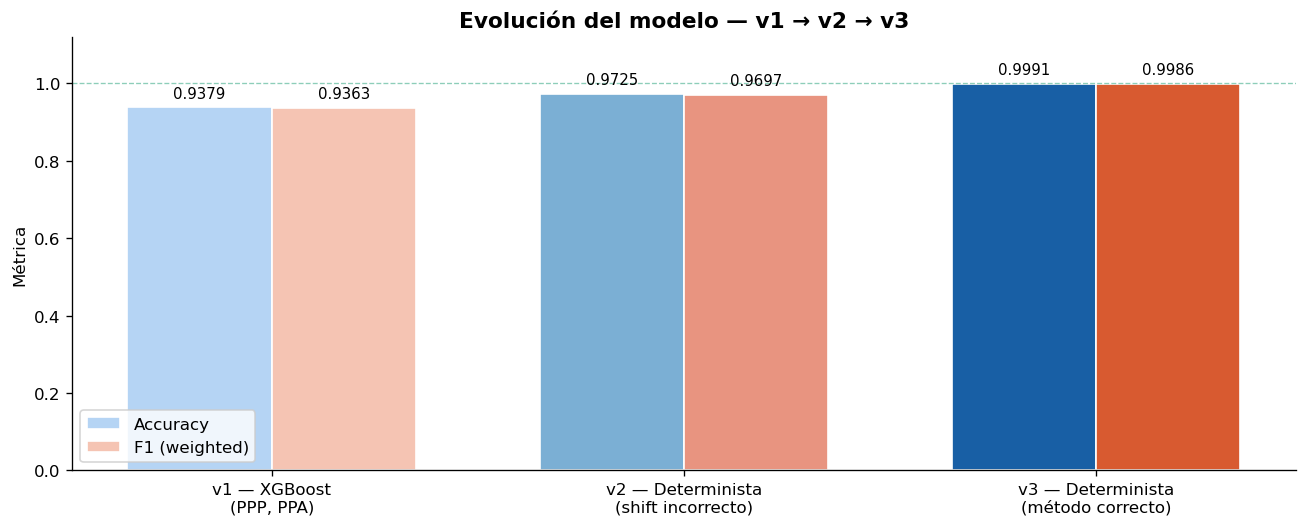

✓ Figura 1 guardada


In [13]:
# ── Figura 1: Comparativa v1 vs v2 vs v3 ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

modelos    = ['v1 — XGBoost\n(PPP, PPA)', 'v2 — Determinista\n(shift incorrecto)', 'v3 — Determinista\n(método correcto)']
accs       = [0.9379, 0.9725, acc]
f1s        = [0.9363, 0.9697, f1]
x = np.arange(len(modelos))
w = 0.35

bars1 = ax.bar(x - w/2, accs, w, label='Accuracy',    color=['#B5D4F4','#7BAFD4','#185FA5'], edgecolor='white')
bars2 = ax.bar(x + w/2, f1s,  w, label='F1 (weighted)', color=['#F5C4B3','#E89480','#D85A30'], edgecolor='white')

ax.set_ylim(0, 1.12)
ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylabel('Métrica'); ax.set_title('Evolución del modelo — v1 → v2 → v3', fontsize=13, fontweight='bold')
ax.bar_label(bars1, fmt='%.4f', padding=4, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=4, fontsize=9)
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#1D9E75', linestyle='--', linewidth=0.8, alpha=0.5, label='100%')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_comparativa_v1_v2_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 1 guardada")


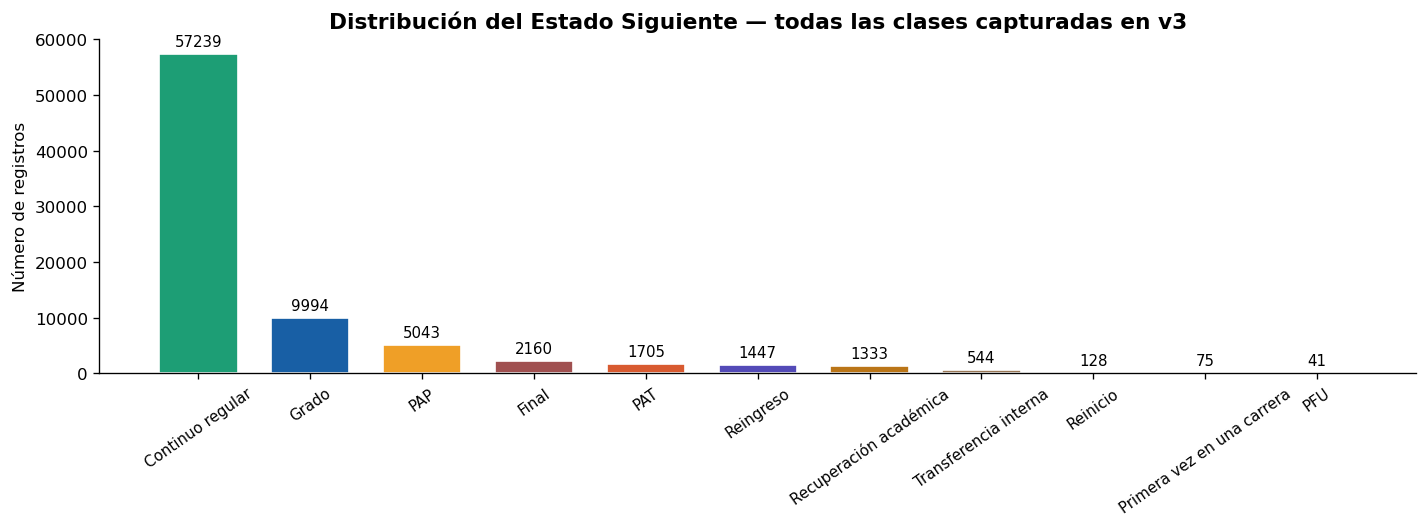

✓ Figura 2 guardada


In [14]:
# ── Figura 2: Distribución del estado siguiente (target) ─────────────────
target_counts = df_train['ESTADO_SIGUIENTE'].value_counts()
colors_t = [PALETTE.get(c,'#888780') for c in target_counts.index]

fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(target_counts.index, target_counts.values, color=colors_t, width=0.7, edgecolor='white')
ax.set_ylabel('Número de registros')
ax.set_title('Distribución del Estado Siguiente — todas las clases capturadas en v3', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.tick_params(axis='x', rotation=35, labelsize=9)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_distribucion_target_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 2 guardada")


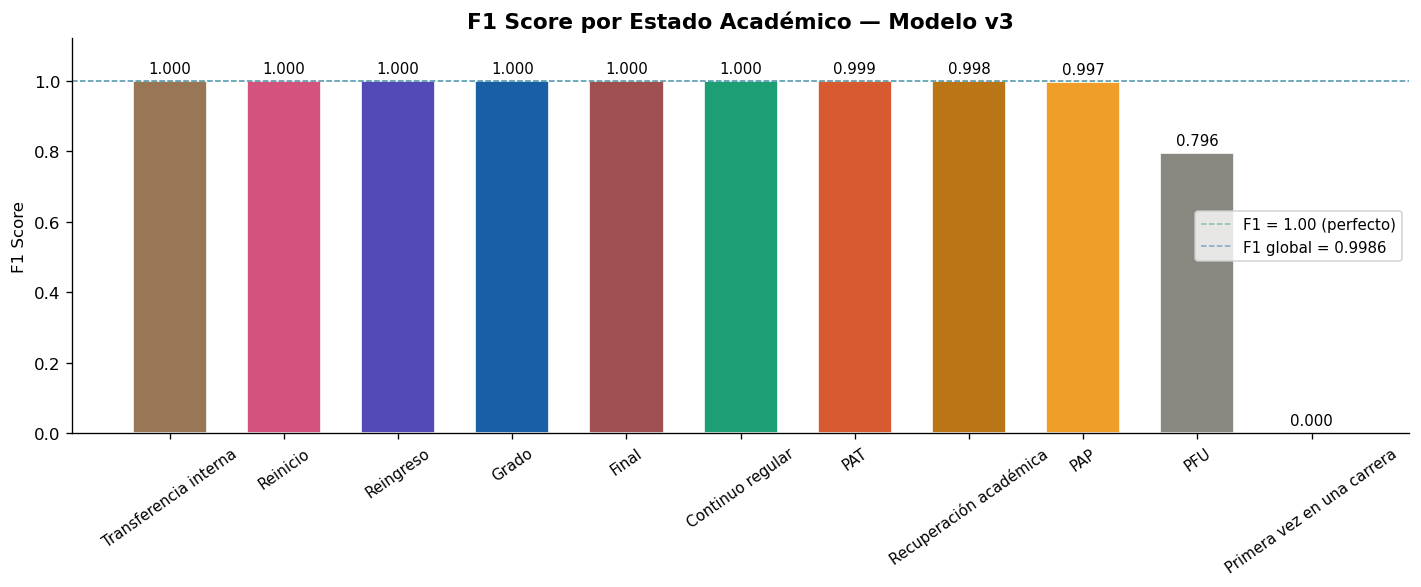

✓ Figura 3 guardada


In [15]:
# ── Figura 3: F1 por clase ───────────────────────────────────────────────
report_dict = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
clases = [k for k in report_dict if k not in ('accuracy','macro avg','weighted avg')]
f1_vals = [report_dict[c]['f1-score'] for c in clases]
sorted_pairs = sorted(zip(f1_vals, clases), reverse=True)
f1_s, cls_s = zip(*sorted_pairs)
colors_c = [PALETTE.get(c,'#888780') for c in cls_s]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cls_s, f1_s, color=colors_c, width=0.65, edgecolor='white')
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score por Estado Académico — Modelo v3', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(y=1.0, color='#1D9E75', linestyle='--', alpha=0.5, linewidth=0.9, label='F1 = 1.00 (perfecto)')
ax.axhline(y=f1,  color='#185FA5', linestyle='--', alpha=0.5, linewidth=0.9, label=f'F1 global = {f1:.4f}')
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.legend(fontsize=9)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_f1_por_clase_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 3 guardada")


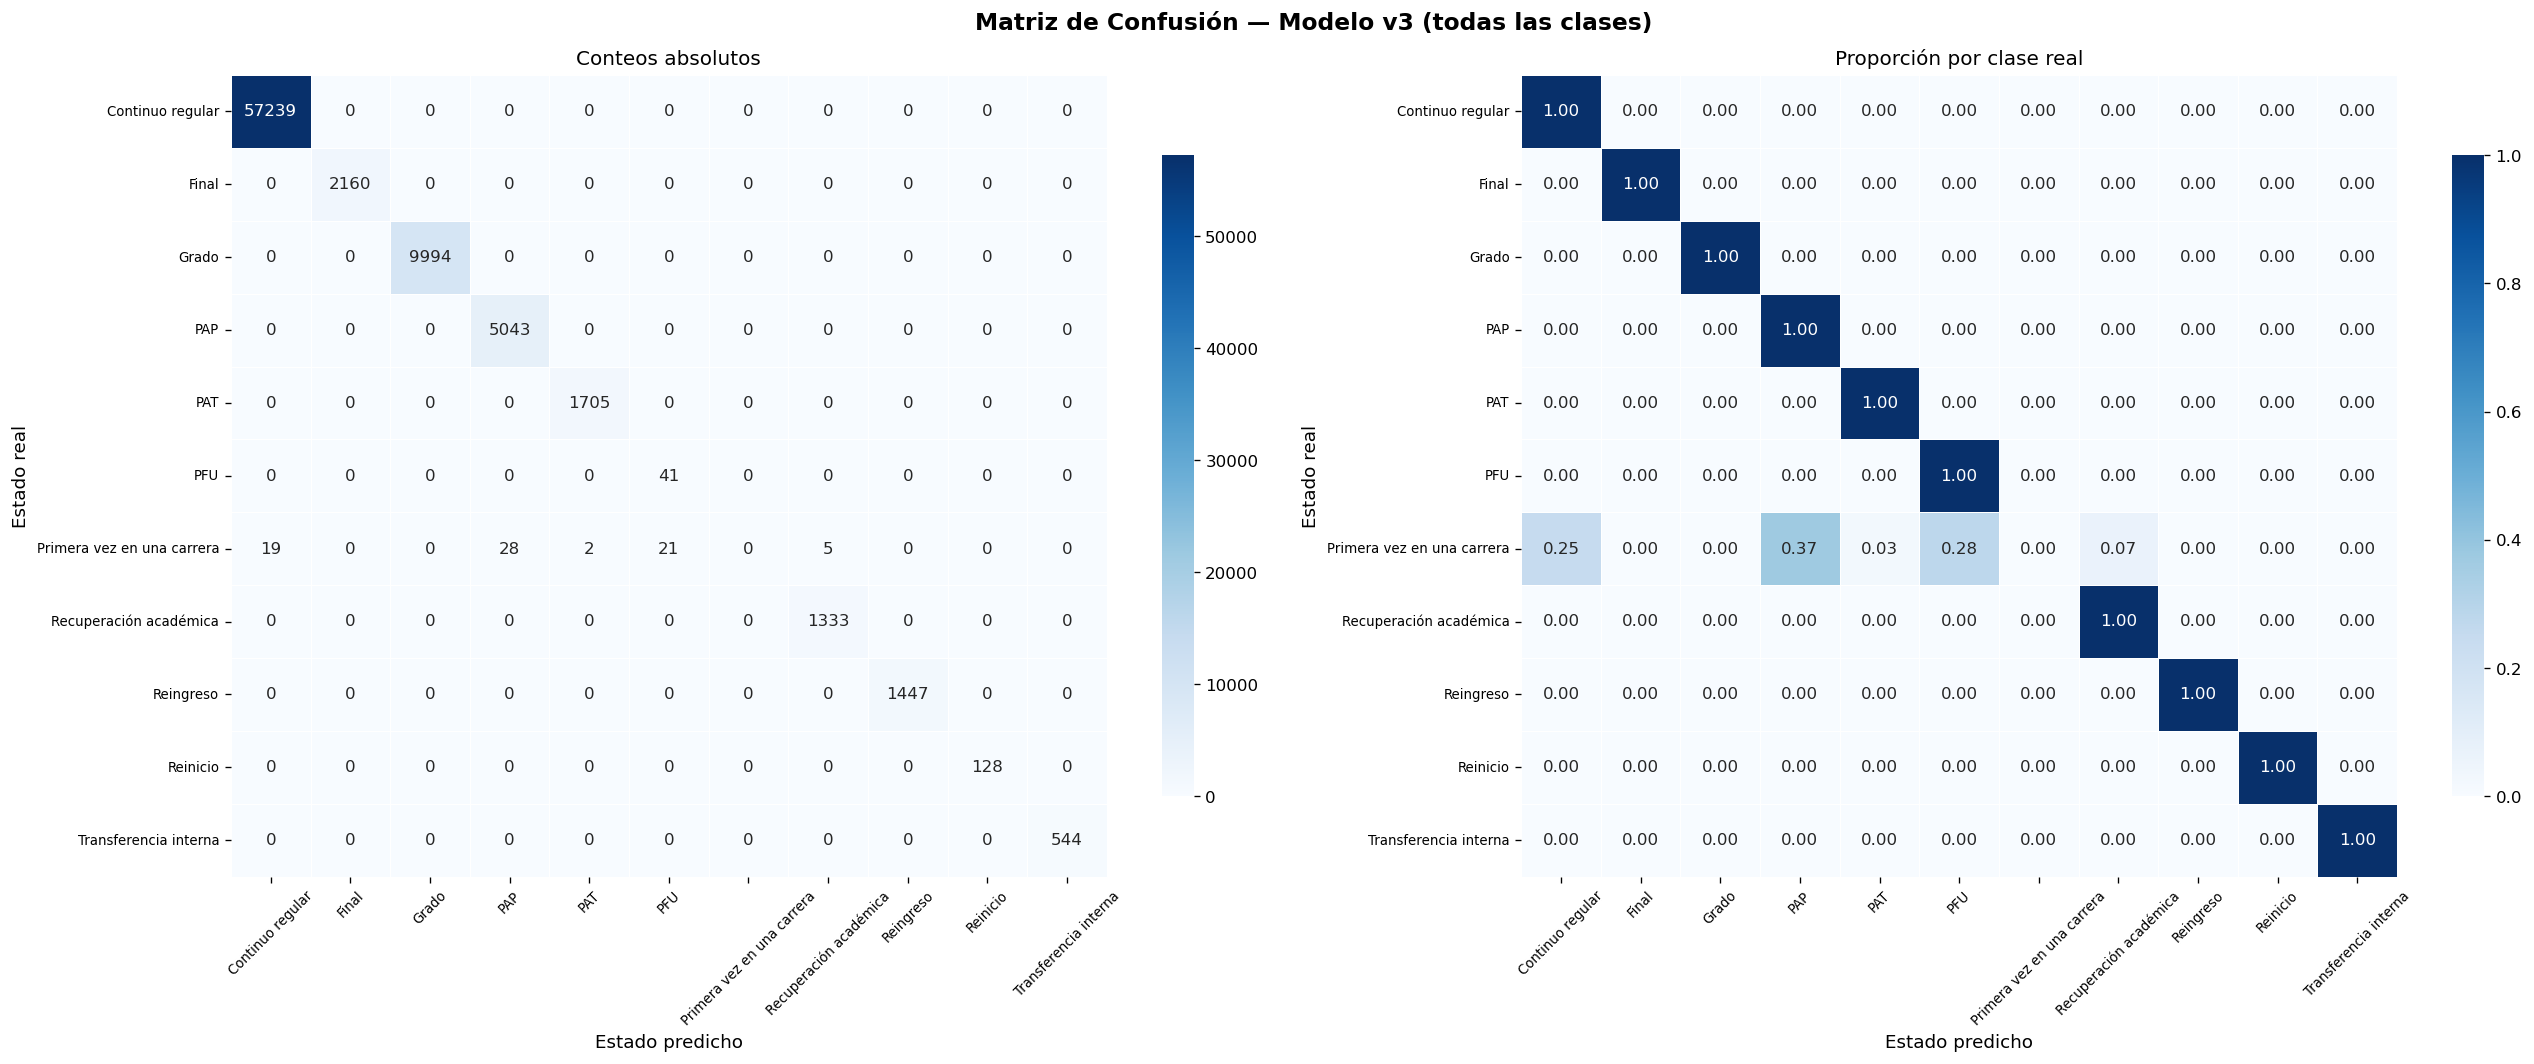

✓ Figura 4 guardada


In [16]:
# ── Figura 4: Matriz de confusión ───────────────────────────────────────
all_classes = sorted(y_true.unique().tolist())
cm      = confusion_matrix(y_true, y_pred, labels=all_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Matriz de Confusión — Modelo v3 (todas las clases)', fontsize=14, fontweight='bold')

for ax_i, data, title, fmt in zip(
    axes,
    [cm,  cm_norm],
    ['Conteos absolutos', 'Proporción por clase real'],
    ['d',  '.2f']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=all_classes, yticklabels=all_classes,
        ax=ax_i, linewidths=0.4, linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    ax_i.set_xlabel('Estado predicho', fontsize=11)
    ax_i.set_ylabel('Estado real', fontsize=11)
    ax_i.set_title(title, fontsize=12)
    ax_i.tick_params(axis='x', rotation=45, labelsize=8)
    ax_i.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 4 guardada")


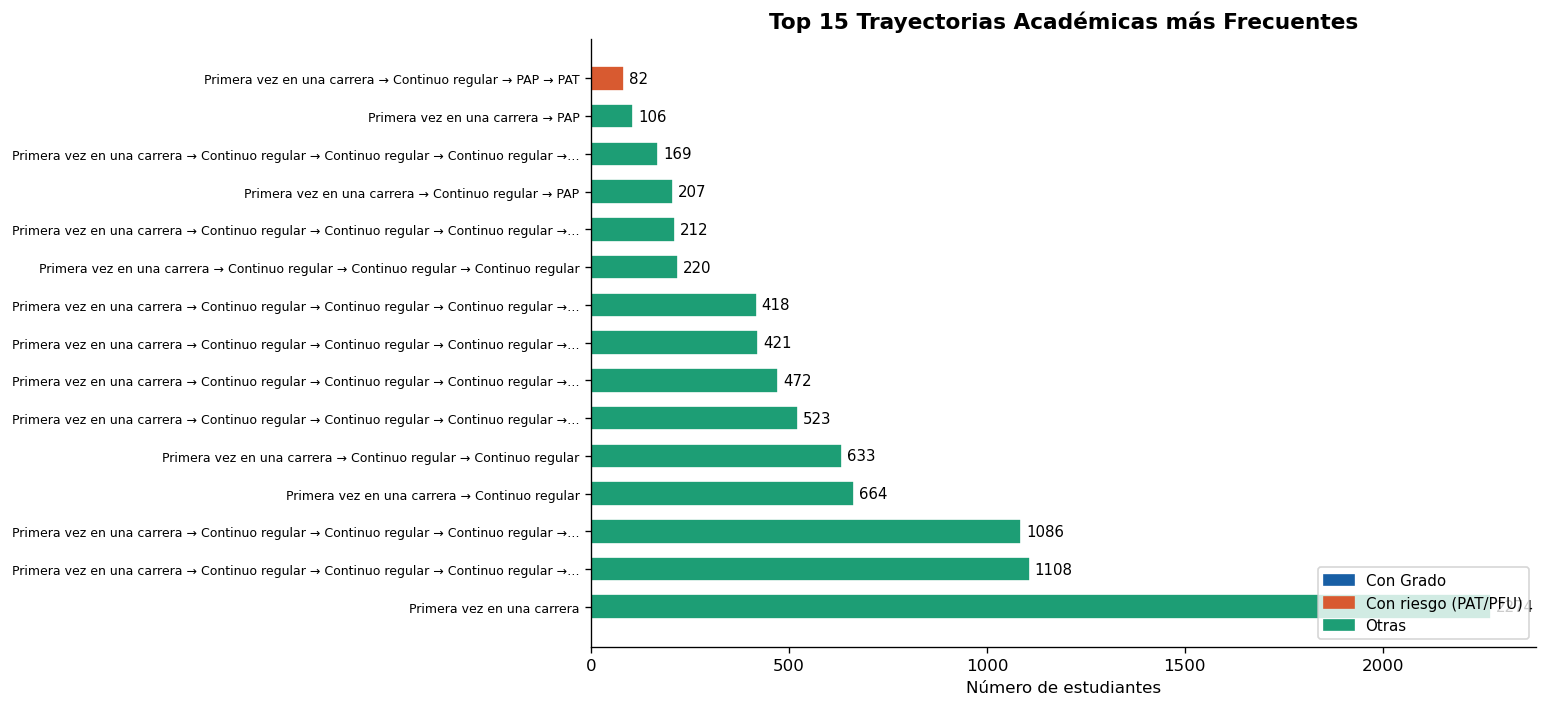

✓ Figura 5 guardada


In [17]:
# ── Figura 5: Top 15 trayectorias más frecuentes ────────────────────────
tray = (
    df_train.groupby('ID')['AUTOMATA_ESTADO']
    .apply(lambda x: ' → '.join(x.tolist()))
    .reset_index(name='TRAYECTORIA')
)
top15 = tray['TRAYECTORIA'].value_counts().head(15)
labels_t = [t[:85]+'…' if len(t)>85 else t for t in top15.index]
colors_t = [
    '#185FA5' if 'Grado' in t else
    '#D85A30' if 'PAT' in t or 'PFU' in t else
    '#1D9E75'
    for t in top15.index
]

fig, ax = plt.subplots(figsize=(13, 6))
y_pos = list(range(len(top15)))
bars = ax.barh(y_pos, top15.values, color=colors_t, height=0.65, edgecolor='white')
ax.set_yticks(y_pos); ax.set_yticklabels(labels_t, fontsize=7.5)
ax.set_xlabel('Número de estudiantes')
ax.set_title('Top 15 Trayectorias Académicas más Frecuentes', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
legend_elements = [
    mpatches.Patch(color='#185FA5', label='Con Grado'),
    mpatches.Patch(color='#D85A30', label='Con riesgo (PAT/PFU)'),
    mpatches.Patch(color='#1D9E75', label='Otras'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_trayectorias_frecuentes_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 5 guardada")


✓ Figura 6 guardada


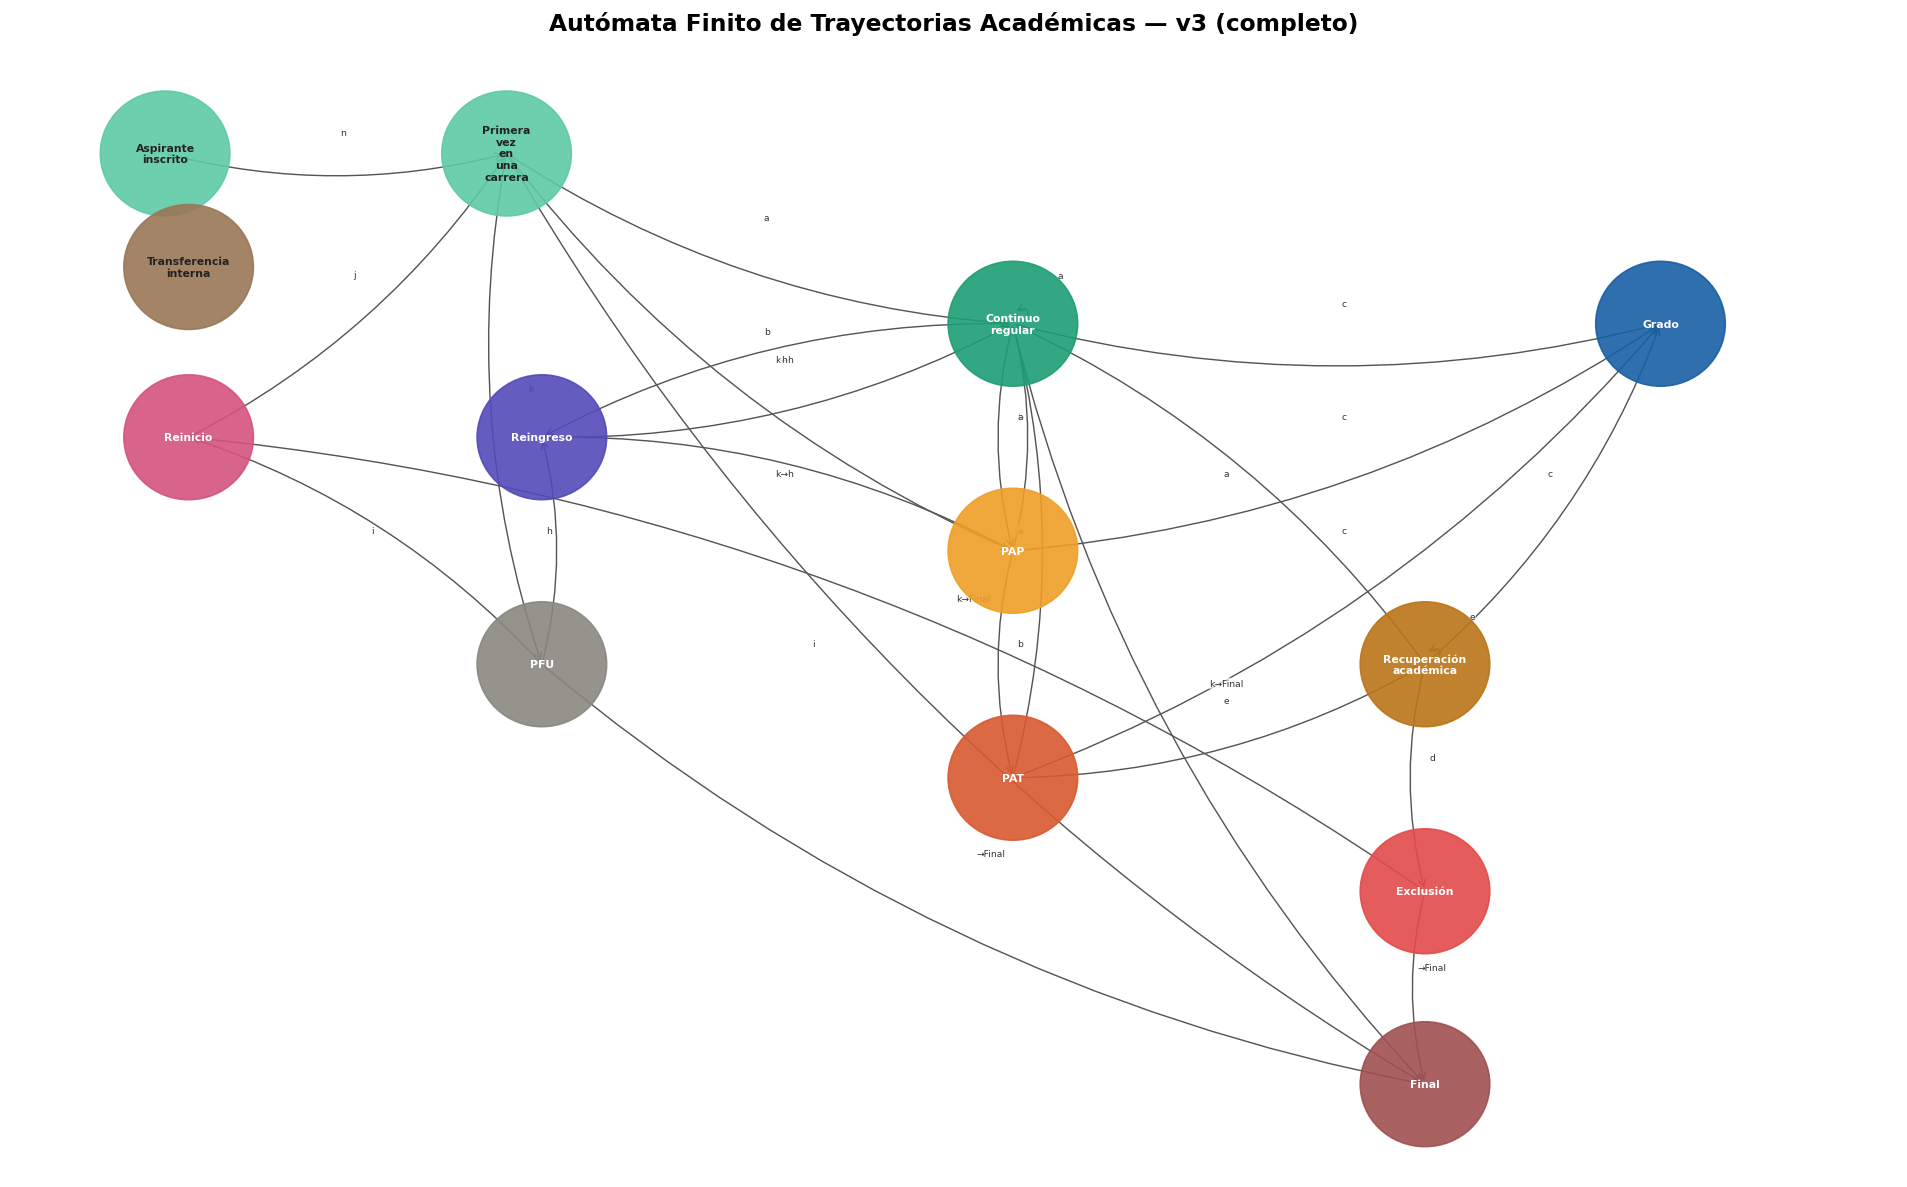

In [19]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Configuración previa (Asegúrate de definir estas variables en tu entorno) ──
# PALETTE = {}  # Define tu paleta aquí si es necesario
# OUTPUT_DIR = "." # Define tu directorio de salida

# ── Figura 6: Diagrama del autómata ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Autómata Finito de Trayectorias Académicas — v3 (completo)', fontsize=14, fontweight='bold')

NPOS = {
    'Aspirante inscrito'         : (1.3, 9.0),
    'Primera vez en una carrera' : (4.2, 9.0),
    'Continuo regular'           : (8.5, 7.5),
    'PAP'                        : (8.5, 5.5),
    'PAT'                        : (8.5, 3.5),
    'Recuperación académica'     : (12.0, 4.5),
    'Exclusión'                  : (12.0, 2.5),
    'Grado'                      : (14.0, 7.5),
    'PFU'                        : (4.5, 4.5),
    'Reingreso'                  : (4.5, 6.5),
    'Reinicio'                   : (1.5, 6.5),
    'Transferencia interna'      : (1.5, 8.0),
    'Final'                      : (12.0, 0.8),
}

# Intenta obtener la paleta, si no existe usa el diccionario por defecto
try:
    NCOLORS = {k: PALETTE.get(k, '#888780') for k in NPOS}
except NameError:
    NCOLORS = {k: '#888780' for k in NPOS}

NCOLORS['Aspirante inscrito'] = '#5DCAA5'
NCOLORS['Transferencia interna'] = '#997756'

EDGES = [
    ('Aspirante inscrito','Primera vez en una carrera','n'),
    ('Primera vez en una carrera','Continuo regular','a'),
    ('Primera vez en una carrera','PAP','b'),
    ('Primera vez en una carrera','PFU','k'),
    ('Primera vez en una carrera','Final','k→Final'),
    ('Continuo regular','Continuo regular','a'),  # Buclé
    ('Continuo regular','PAP','b'),
    ('Continuo regular','Grado','c'),
    ('Continuo regular','Reingreso','k→h'),
    ('Continuo regular','Final','k→Final'),
    ('PAP','Continuo regular','a'),
    ('PAP','PAT','b'),
    ('PAP','Grado','c'),
    ('PAP','Reingreso','k→h'),
    ('PAT','Continuo regular','a'),
    ('PAT','Recuperación académica','e'),
    ('PAT','Grado','c'),
    ('Recuperación académica','Continuo regular','a'),
    ('Recuperación académica','Recuperación académica','e'),  # Buclé
    ('Recuperación académica','Grado','c'),
    ('Recuperación académica','Exclusión','d'),
    ('PFU','Reingreso','h'),
    ('PFU','Reinicio','i'),
    ('PFU','Final','→Final'),
    ('Reingreso','Continuo regular','h'),
    ('Exclusión','Reinicio','i'),
    ('Exclusión','Final','→Final'),
    ('Reinicio','Primera vez en una carrera','j'),
]

# Estilo estándar para líneas entre nodos diferentes
arrowprops_normal = dict(arrowstyle='->', color='#555', lw=0.85, connectionstyle='arc3,rad=0.13')
# Estilo curvado especial para que los bucles (src == dst) se alcancen a ver
arrowprops_loop = dict(arrowstyle='->', color='#555', lw=0.85, connectionstyle='arc3,rad=1.4')

for src, dst, lbl in EDGES:
    if src not in NPOS or dst not in NPOS: 
        continue
    
    x1, y1 = NPOS[src]
    x2, y2 = NPOS[dst]
    
    if src == dst:
        # Tratamiento para bucles sobre el mismo nodo
        ax.annotate('', xy=(x2, y2 + 0.1), xytext=(x1 + 0.1, y1), arrowprops=arrowprops_loop, zorder=2)
        mx, my = x1 + 0.4, y1 + 0.4  # Desplazar la etiqueta para que no tape el nodo
    else:
        # Transiciones normales
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrowprops_normal, zorder=2)
        mx, my = (x1 + x2) / 2 + 0.06, (y1 + y2) / 2 + 0.16
        
    ax.text(mx, my, lbl, fontsize=5.5, color='#333', ha='center',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))

for state, (x, y) in NPOS.items():
    c = NCOLORS.get(state, '#888780')
    ax.add_patch(plt.Circle((x, y), 0.55, color=c, zorder=3, alpha=0.9))
    
    # LÍNEA CORREGIDA: Se cambió el salto físico por '\n'
    lbl = state.replace(' ', '\n') if len(state) > 14 else state
    
    fc = 'white' if c not in ['#5DCAA5', '#997756'] else '#222'
    ax.text(x, y, lbl, ha='center', va='center', fontsize=6.5,
            fontweight='bold', zorder=4, color=fc)

plt.tight_layout()

# Verificar o crear el directorio de salida si no existe
try:
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(f'{OUTPUT_DIR}/06_automata_completo_v3.png', dpi=150, bbox_inches='tight')
    print("✓ Figura 6 guardada")
except NameError:
    plt.savefig('06_automata_completo_v3.png', dpi=150, bbox_inches='tight')
    print("✓ Figura 6 guardada en el directorio actual")

plt.show()

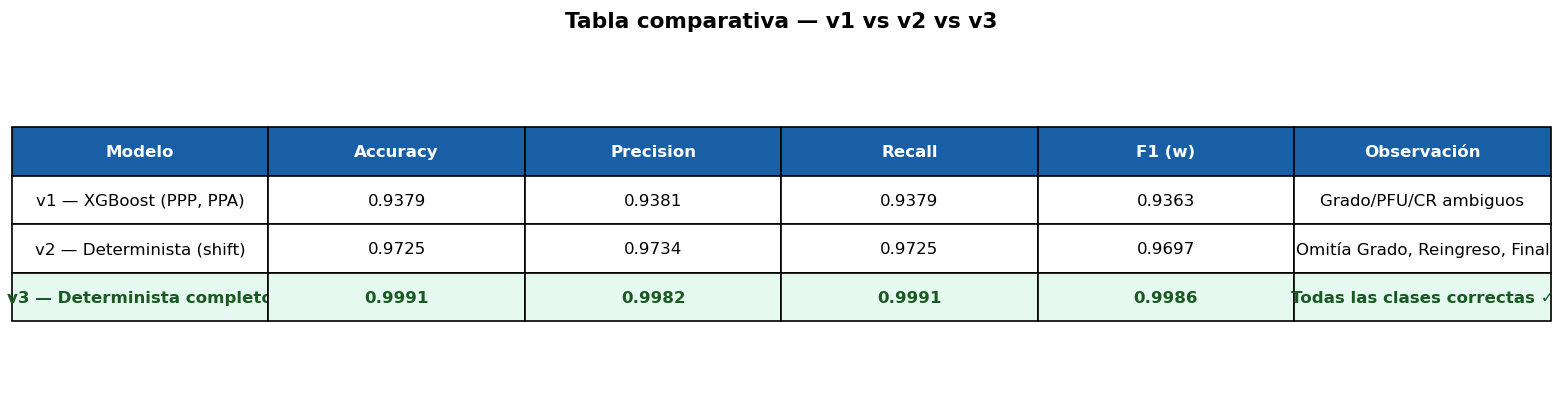

✓ Figura 7 guardada


In [20]:
# ── Figura 7: Tabla comparativa de versiones ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')

table_data = [
    ['v1 — XGBoost (PPP, PPA)',              '0.9379', '0.9381', '0.9379', '0.9363',
     'Grado/PFU/CR ambiguos'],
    ['v2 — Determinista (shift)',             '0.9725', '0.9734', '0.9725', '0.9697',
     'Omitía Grado, Reingreso, Final'],
    [f'v3 — Determinista completo',          f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}',
     'Todas las clases correctas ✓'],
]
col_labels = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1 (w)', 'Observación']
tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.3)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#185FA5')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for j in range(len(col_labels)):
    tbl[3, j].set_facecolor('#E6F9F0')
    tbl[3, j].set_text_props(fontweight='bold', color='#185A20')
ax.set_title('Tabla comparativa — v1 vs v2 vs v3', fontsize=13, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_tabla_comparativa_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 7 guardada")


## Fase 6 — Exportar resultados

In [21]:
# Dataset de entrenamiento completo con predicciones
export_cols = [
    'ID','PERIODO','PROGRAMA','AUTOMATA_ESTADO','TRANSICION_AUTOMATA',
    'PROMEDIO','PROMEDIO_ACUMULADO','NRO_CURSOS_APROBADOS','CREDITOS_APROVADOS',
    'RIESGO_EXCLUSION','TUVO_RIESGO_EXCLUSION',
    'REGLA_SIGUIENTE','ESTADO_SIGUIENTE','PRED_V3'
]
export_cols = [c for c in export_cols if c in df_train.columns]
df_train[export_cols].to_csv(
    f'{OUTPUT_DIR}/training_dataset_v3.csv', index=False, encoding='utf-8-sig'
)
print(f"✓ training_dataset_v3.csv  ({len(df_train):,} filas)")


✓ training_dataset_v3.csv  (79,709 filas)


In [22]:
# Trayectorias completas por estudiante
tray_full = df_train.groupby('ID').agg(
    PROGRAMA               = ('PROGRAMA',          'first'),
    N_PERIODOS             = ('PERIODO',            'count'),
    SECUENCIA_ESTADOS      = ('AUTOMATA_ESTADO',    lambda x: ' → '.join(x.tolist())),
    SECUENCIA_TRANSICIONES = ('TRANSICION_AUTOMATA',lambda x: ''.join(x.fillna('?').tolist())),
    ESTADO_FINAL_PRED      = ('PRED_V3',            'last'),
    ESTADO_FINAL_REAL      = ('ESTADO_SIGUIENTE',   'last'),
).reset_index()

tray_full.to_csv(f'{OUTPUT_DIR}/trayectorias_v3.csv', index=False, encoding='utf-8-sig')
print(f"✓ trayectorias_v3.csv  ({len(tray_full):,} estudiantes)")


✓ trayectorias_v3.csv  (12,154 estudiantes)


In [23]:
# Métricas en JSON
metrics_out = {
    'version'            : 'v3 — predictor determinista completo',
    'accuracy'           : float(acc),
    'f1_weighted'        : float(f1),
    'precision_weighted' : float(prec),
    'recall_weighted'    : float(rec),
    'n_total'            : int(n_total),
    'n_correct'          : int(n_correct),
    'n_discrepancias'    : int(n_total - n_correct),
    'pct_discrepancias'  : float((n_total - n_correct) / n_total),
    'classification_report': classification_report(y_true, y_pred, zero_division=0, output_dict=True),
    'comparativa': {
        'v1_xgboost'     : {'accuracy': 0.9379, 'f1': 0.9363},
        'v2_determinista': {'accuracy': 0.9725, 'f1': 0.9697},
        'v3_completo'    : {'accuracy': float(acc), 'f1': float(f1)},
    }
}
with open(f'{OUTPUT_DIR}/metrics_v3.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, ensure_ascii=False, indent=2)
print(f"✓ metrics_v3.json")


✓ metrics_v3.json


## Resumen final

In [24]:
print("=" * 65)
print("RESUMEN FINAL — MODELO v3")
print("=" * 65)
print(f"  Accuracy        : {acc:.4f}")
print(f"  F1 (weighted)   : {f1:.4f}")
print(f"  Total evaluadas : {n_total:,}")
print(f"  Correctas       : {n_correct:,}")
print()

# Estados finales de los estudiantes
ef = tray_full['ESTADO_FINAL_REAL'].value_counts()
print("  Estados finales de los estudiantes:")
for estado, cnt in ef.items():
    pct = cnt / len(tray_full) * 100
    print(f"    {estado:<35} {cnt:>5,}  ({pct:5.1f}%)")

print()
print(f"  Archivos generados en: {OUTPUT_DIR}/")
print("    01_comparativa_v1_v2_v3.png")
print("    02_distribucion_target_v3.png")
print("    03_f1_por_clase_v3.png")
print("    04_confusion_matrix_v3.png")
print("    05_trayectorias_frecuentes_v3.png")
print("    06_automata_completo_v3.png")
print("    07_tabla_comparativa_v3.png")
print("    training_dataset_v3.csv")
print("    trayectorias_v3.csv")
print("    metrics_v3.json")
print("=" * 65)


RESUMEN FINAL — MODELO v3
  Accuracy        : 0.9991
  F1 (weighted)   : 0.9986
  Total evaluadas : 79,709
  Correctas       : 79,634

  Estados finales de los estudiantes:
    Grado                               9,994  ( 82.2%)
    Final                               2,160  ( 17.8%)

  Archivos generados en: ./outputs_v3/
    01_comparativa_v1_v2_v3.png
    02_distribucion_target_v3.png
    03_f1_por_clase_v3.png
    04_confusion_matrix_v3.png
    05_trayectorias_frecuentes_v3.png
    06_automata_completo_v3.png
    07_tabla_comparativa_v3.png
    training_dataset_v3.csv
    trayectorias_v3.csv
    metrics_v3.json
